# Online Portfolio Selection



Online portfolio selection (OPS) may be viewed as an instance of online convex optimization(OCO)

In each of $t = 1, . . . , T$ rounds, a learner has to make a prediction $x_t$ in a convex domain $X$ **before observing a convex loss function** $f_t : X \rightarrow R$.

**The goal** is to obtain a guaranteed bound on the regret $$Regret_T = \sum_{t=1}^T f_t(x_t) −\min_{x \in X} \sum_{t=1}^T f_t(x)$$

**Online portfolio selection** corresponds to the special case that the domain $X = \{x \in \mathbb{R}^n_+| \sum_{i=1}^n x_i = 1\}$ is the **probability simplex**.

The **loss functions** are restricted to be of the form $f_t(x) = -\ln(<x, r_t>)$ for vectors $r_t \in \mathbb{R}^n_+$.


-------------------------------------------------------------- ------------------------------------------------
$n$ - кол-во стоков

$r_{t,i}$ интерпретировать как цена стока $i$ на момент $t$.

$x_{t, i}$ - доля инвестиций в $i$



----------------------------------------------------- ---------------------------------------------------------------------------


В работах до 2000-го: $Regret_T = O(d \ln T)$

Достигается с помощью выбора $x_{t+1}$ на экспотенциальном распределении: $dP_{t+1}(x) \sim e^{-\sum_{s=1}^t f_s(x)} d \pi(x)$
здесь $\pi$ - Dirichlet-ptior

Но run-time -> $O(T^d)$

Что если использовать стратегию? follow-the--leader:
$$x_{t+1} = argmin_{x \in X}\sum_{s=1}^t f_s(x) -> argmax_{x \in X} ln(<x, r_t>)$$



# Experiments on Simulated and Real Market Data

In [ ]:
import cvxpy as cp
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

!pip install yfinance
import yfinance as yf
import pandas as pd
import string
import random

sns.set_context("notebook")
plt.rcParams["figure.figsize"] = (16, 8)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 11.1 MB/s eta 0:00:00a 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for peewee: filename=peewee-3.17.9-cp312-cp312-linux_x86_64.whl size=301983 sha256=6ac2024827bdf9585e9602c7fa222503ce954596ddd82200fc1decda6a57181e
  Stored in directory: /home/nikita/.cache/pip/wheels/43/ef/2d/2c51d496bf084945ffdf838b4cc8767b8ba1cc20eb41588831
Successfully built peewee


The Best Constantly rebalanced portfolio (BCRP) solves:
$$x^* = argmax_{x \in \Delta_n} \sum_{t=1}^T log(<r_t, x>)$$

In [ ]:
def Best_Constantly_Rebalanced_Portfolio(r):
    T = r.shape[0]
    n = r.shape[1]
    if T == 0:
        return np.ones(n) / n

    x = cp.Variable(n)

    obj = cp.sum(cp.log(r @ x))
    prob = cp.Problem(cp.Maximize(obj), [cp.sum(x) == 1, x >= 0])
    prob.solve()
    return x.value


Follow the leader(FTL) solves

$$x_t = argmax_{x \in \Delta_n} \sum_{i=1}^{t-1} log(<r_i, x>)$$

In [ ]:
"""
FTL uses the BCRP on the returns seen so far.
"""


def Follow_The_Leader(r):
    T = len(r)
    n = len(r[0])
    x = np.zeros((T, n))
    for t in range(T):
        x[t] = Best_Constantly_Rebalanced_Portfolio(r[:t])
    return x

# Simulation Experiment

In [ ]:
# Number of stocks
n = 10

# Create dummy stock labels
dummy_stocks = ["".join(random.choices(string.ascii_uppercase, k=5)) for i in range(n)]

# Number of days
T = 700

# Log-normal returns
r = np.exp(np.random.normal(0, 0.01, size=(T, n)))
df = pd.DataFrame(data=r.cumprod(axis=0), columns=dummy_stocks)

<Axes: >

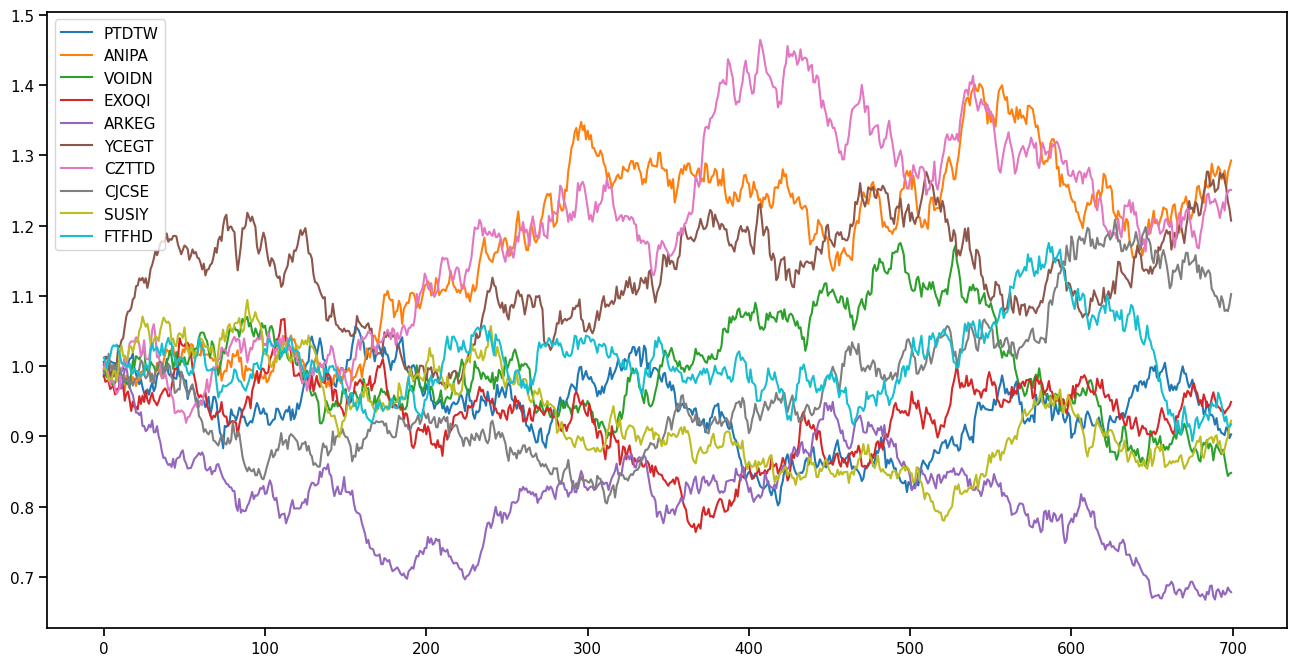

In [ ]:
df.plot()

In [ ]:
ftl = Follow_The_Leader(r)
df["FTL"] = np.cumprod(np.sum(r * ftl, axis=1))

/home/nikita/.local/share/mamba/lib/python3.12/site-packages/cvxpy/problems/problem.py:1504: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


In [ ]:
bcrp = Best_Constantly_Rebalanced_Portfolio(r)
df["BCRP"] = np.cumprod(r @ bcrp)

In [11]:
bcrp

array([2.85331429e-11, 7.13058624e-01, 2.20045491e-11, 3.62780051e-11,
       9.84693617e-12, 6.06425122e-10, 2.86941375e-01, 9.41988870e-11,
       3.09837566e-11, 2.94673634e-11])

<Axes: >

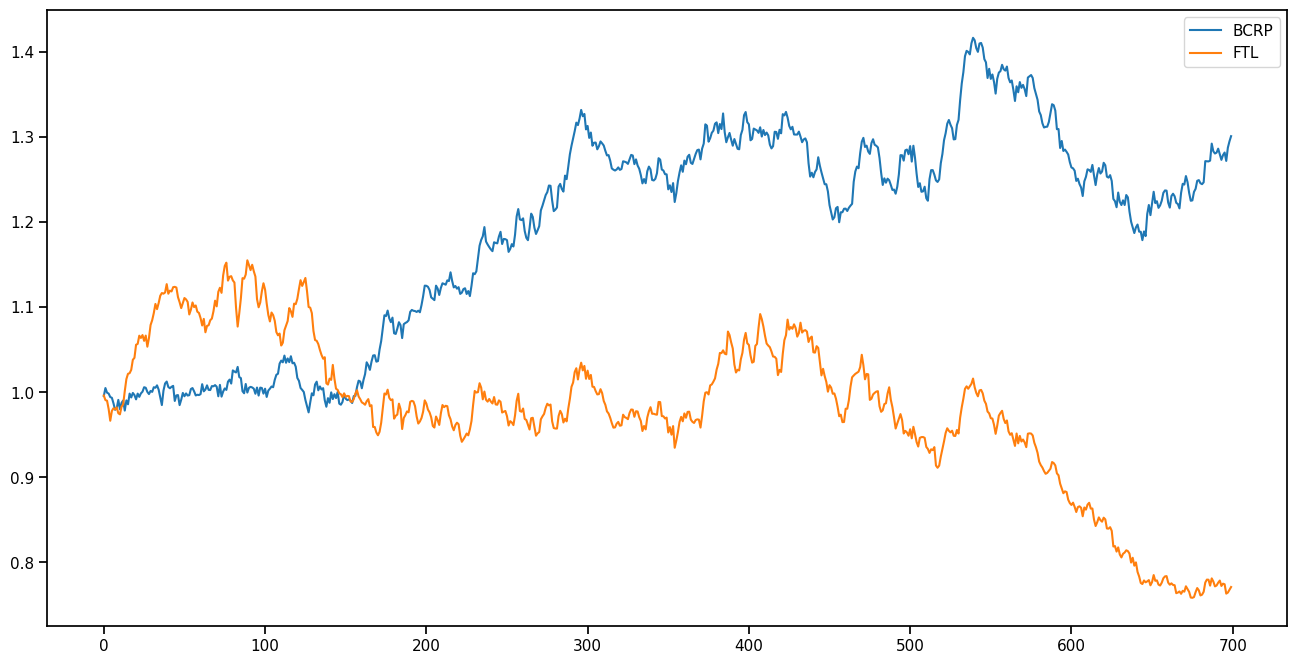

In [ ]:
df[["BCRP", "FTL"]].plot()


# Market Data

market data from Yahoo Finance and compute returns

In [ ]:
# Date range
start = "2023-03-25"
end = "2025-03-25"

# Tickers of assets
assets = ["TGT", "AAPL", "AMZN", "JPM", "NFLX", "XOM", "MSFT", "VZ", "GOOG", "META"]
assets.sort()

# Downloading data
data = yf.download(assets, start=start, end=end)

data.columns

YF.download() has changed argument auto_adjust default to True


[**********************80%*************          ]  8 of 10 completedFailed to get ticker 'VZ' reason: HTTPSConnectionPool(host='query2.finance.yahoo.com', port=443): Max retries exceeded with url: /v8/finance/chart/VZ?range=1d&interval=1d&crumb=DVN2YskOpSR (Caused by SSLError(SSLEOFError(8, '[SSL: UNEXPECTED_EOF_WHILE_READING] EOF occurred in violation of protocol (_ssl.c:1010)')))
[*********************100%***********************]  10 of 10 completed


MultiIndex([( 'Close', 'AAPL'),
            ( 'Close', 'AMZN'),
            ( 'Close', 'GOOG'),
            ( 'Close',  'JPM'),
            ( 'Close', 'META'),
            ( 'Close', 'MSFT'),
            ( 'Close', 'NFLX'),
            ( 'Close',  'TGT'),
            ( 'Close',   'VZ'),
            ( 'Close',  'XOM'),
            (  'High', 'AAPL'),
            (  'High', 'AMZN'),
            (  'High', 'GOOG'),
            (  'High',  'JPM'),
            (  'High', 'META'),
            (  'High', 'MSFT'),
            (  'High', 'NFLX'),
            (  'High',  'TGT'),
            (  'High',   'VZ'),
            (  'High',  'XOM'),
            (   'Low', 'AAPL'),
            (   'Low', 'AMZN'),
            (   'Low', 'GOOG'),
            (   'Low',  'JPM'),
            (   'Low', 'META'),
            (   'Low', 'MSFT'),
            (   'Low', 'NFLX'),
            (   'Low',  'TGT'),
            (   'Low',   'VZ'),
            (   'Low',  'XOM'),
            (  'Open', 'AAPL'),
        

In [14]:
data = data.loc[:, ("Close", slice(None))]
data.columns = assets

# Calculating returns

df = 1 + data[assets].pct_change().dropna() / 100
r = df.to_numpy()
df = df.cumprod(axis=0)

<Axes: xlabel='Date'>

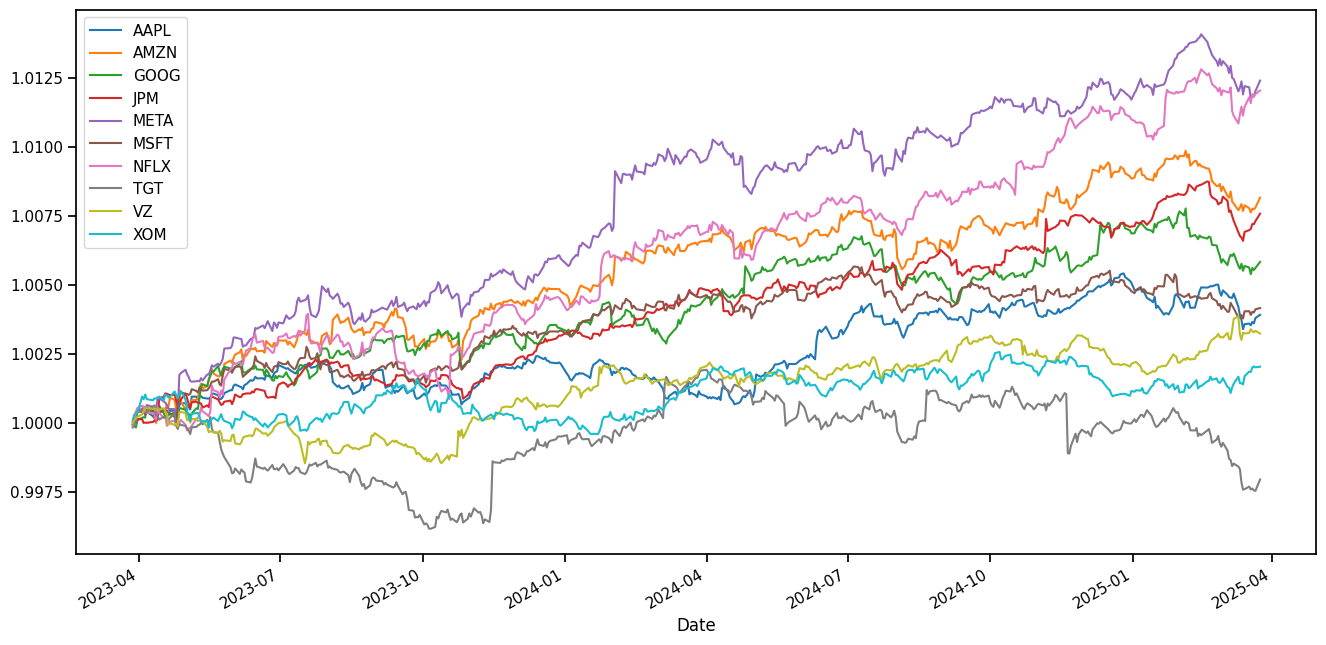

In [15]:
df.plot()

In [16]:
ftl = Follow_The_Leader(r)
df["FTL"] = np.cumprod(np.sum(r * ftl, axis=1))

/home/nikita/.local/share/mamba/lib/python3.12/site-packages/cvxpy/problems/problem.py:1504: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


In [17]:
bcrp = Best_Constantly_Rebalanced_Portfolio(r)
df["BCRP"] = np.cumprod(r @ bcrp)

<Axes: xlabel='Date'>

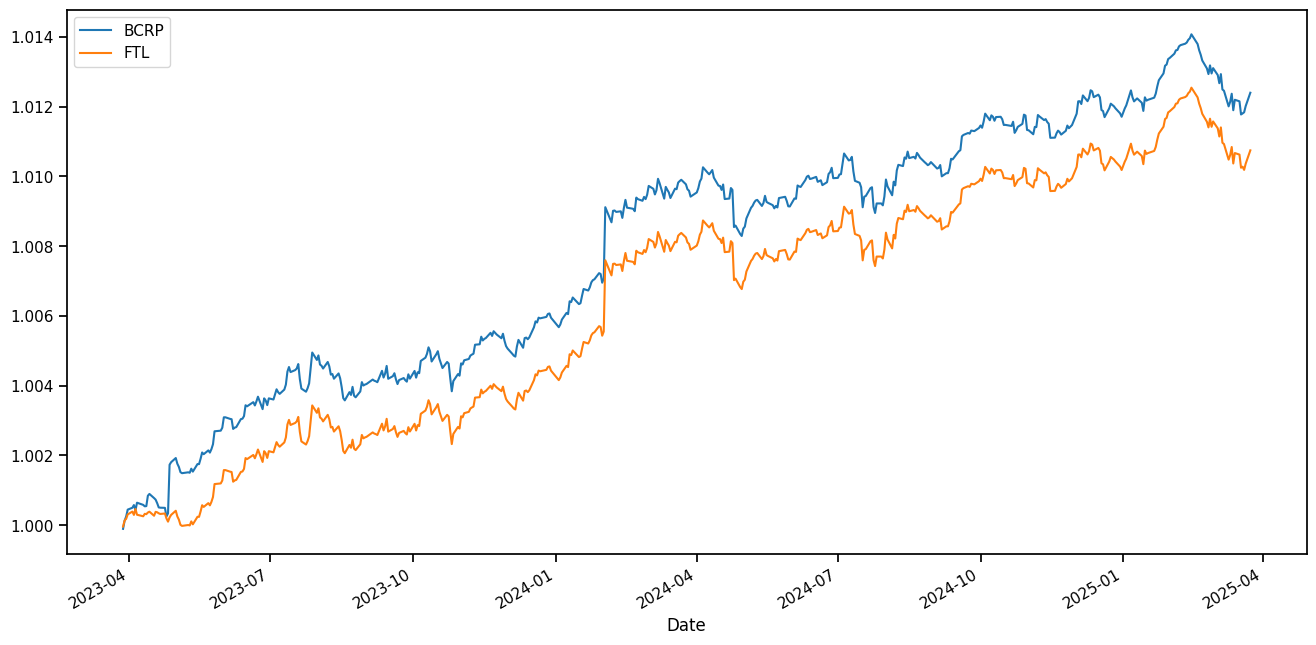

In [24]:
df[["BCRP", "FTL"]].plot()

# Online Portfolio Selection - Exponentiated Gradient

# Simple Regret Bound

**The goal** is to obtain a guaranteed bound on the regret
$$R_T(Alg, r_{t=1}^T, x) = \sum_{t=1}^T \log (r_t^T x) - \log(r_t^T x_t) = \sum_{t=1}^T f_t (x_t) - f_t(x)$$

Since $f_t$ **is convex** in $x$, we have simple upper bound:
$$f_t(x_t) - f_t(x) \leq \nabla f_t(x_t)^T (x_t - x)$$

**Regret bound**: $$\sum_{t=1}^T f_t (x_t) - f_t(x) \leq \sum_{t=1}^T \nabla f_t(x_t)^T (x_t-x)$$

**Linearizing** $$f_t(x) \sim f_t(x_t) + \nabla f_t(x_t)^T(x-x_t)$$


# Linearized Follow-The-Regularized-Leader

We could use a strategy that just uses gradients $\nabla f_t(x_t) = - \frac{r_t}{r_t^T x_t}$ instead of the function $f_t(x)$ for its update.

**BEFORE** $$x_{t} = argmin_{x \in \Delta_n}\sum_{i=1}^{t-1} f_i(x) -> argmax_{x \in \Delta_n}\sum_{i=1}^{t-1} ln(<x, r_i>)$$

**AFTER** $$x_t = argmin_{x\in \Delta_n}\sum_{i=1}^{t-1}\nabla f_i(x_i)^T x$$




One way to stabilize linearized FTL is by adding convex regularization. This algorithm is called linearized Follow-The-Regularized-Leader (FTRL).


$$x_t = argmin_{x\in \Delta_n}[R(x) + \eta_t \sum_{i=1}^{t-1}\nabla f_i(x_i)^T x]$$

Here $R(x)$ is the convex regularizer, and $\eta_t$ is the learning rate.


# КАКОЙ РЕГУЛЯРИЗАТОР ВЫБИРАТЬ?

## Exponentiated Gradient Descent
Picking the right regularizer for a problem is an art. Choosing a regularizer that conforms to the geometry of the problem is a good starting point. In this case, since the domain is $\Delta_n$ a suitable regularizer is **negative Shannon entropy.**

$$R(x) = \sum_{j=1}^{n} x_j log(x_j) -> \sum_{j=1}^{n} x[j] log(x[j])$$



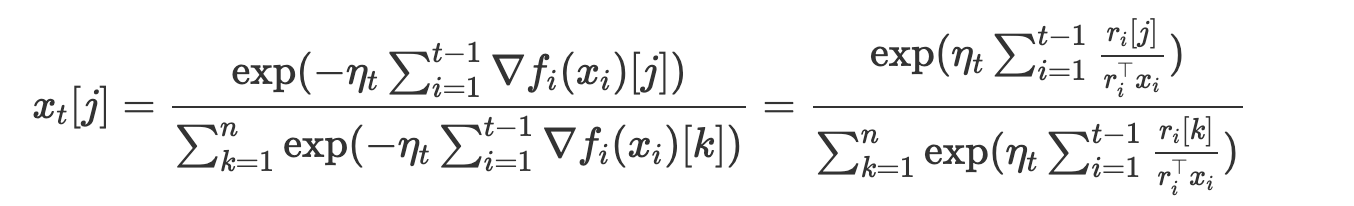

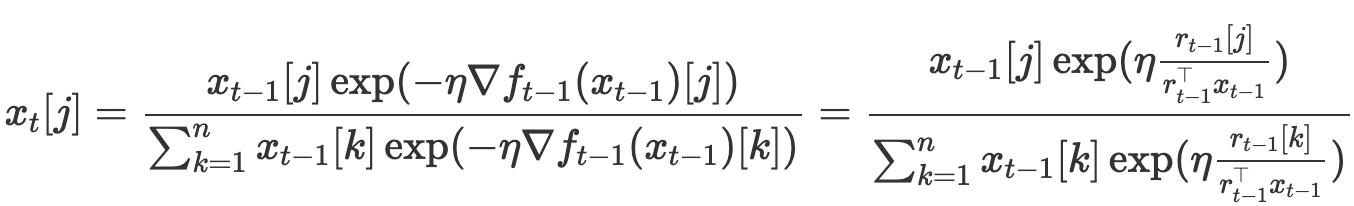

If the returns are uniformly **lowerbounded by a known constant** $r$:
$$1\geq r_t[i]\geq r > 0$$

Then picking $\eta = 2r\sqrt{2 log(n)/T}$, we get the regret bound:
$R_T(EG(\eta), r_{1}^T, x) \leq \sum_{t=1}^T \nabla f_t(x_t)^T(x_t-x)\leq \frac{1}{r}\sqrt{\frac{1}{2}T log(n)}$

**For this choice** $\eta$, we need to know $T$ and $r$ **beforehand.**
----------------------------------------------------------------------------
-------------------------------------------------------------------------------
If $T$ is unknown, we can employ an adaptive algorithm called **AdaHedge**. We get an adaptive regret bound:

$$R_T(AdaHedge, r_1^T, x) \leq O(\sqrt{log(n) \sum_{t=1}^T\frac{1}{(min_i\ r_t[i])^2}}\ )$$

ВОТ [ЗДЕСЬ ](https://arxiv.org/pdf/1912.13213)МОЖНО ПОСМОТРЕТЬ AdaHedge

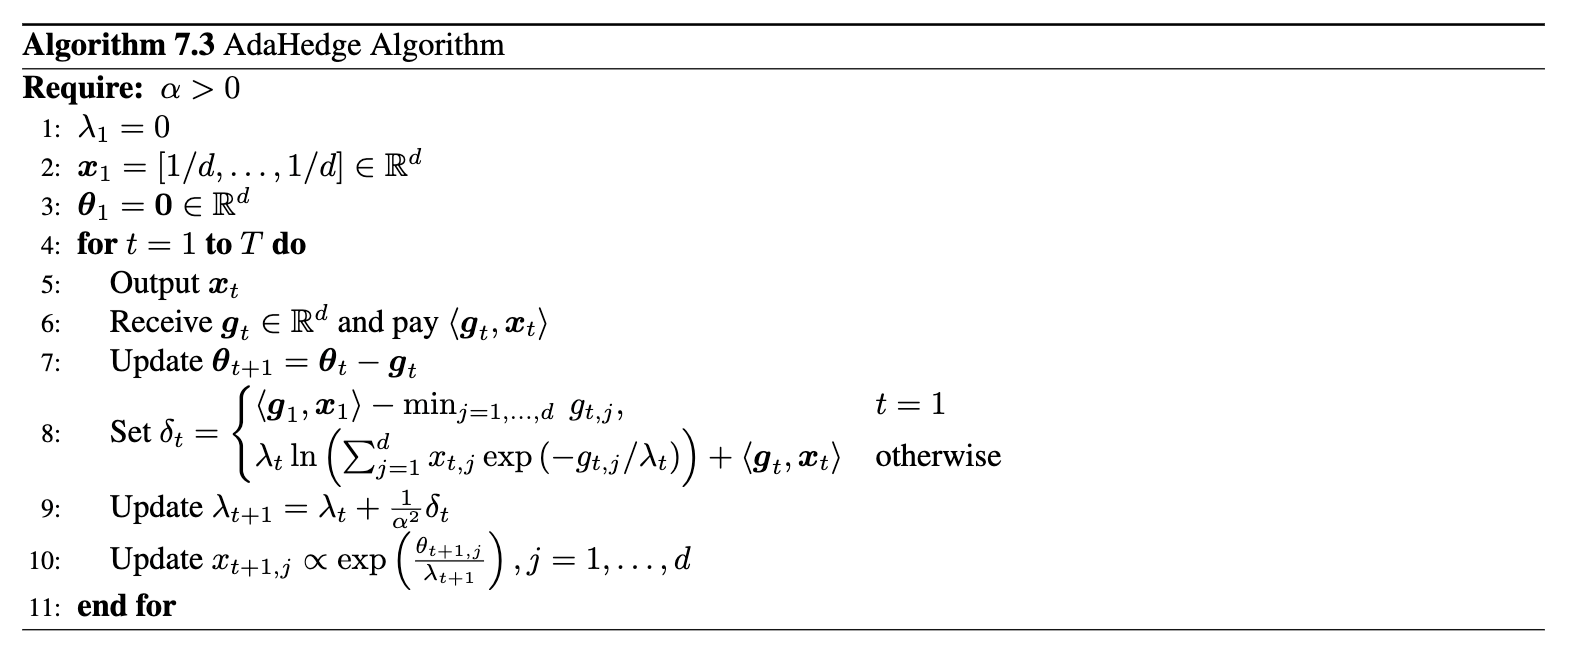

**А МОЖНО КАК-ТО ИЗБАВИТЬСЯ ОТ $r$ В РЕГРЕТЕ?**

$$\tilde{r}_t ← (1-\frac{\alpha_t}{n})r_t + \frac{\alpha_t}{n} 1$$

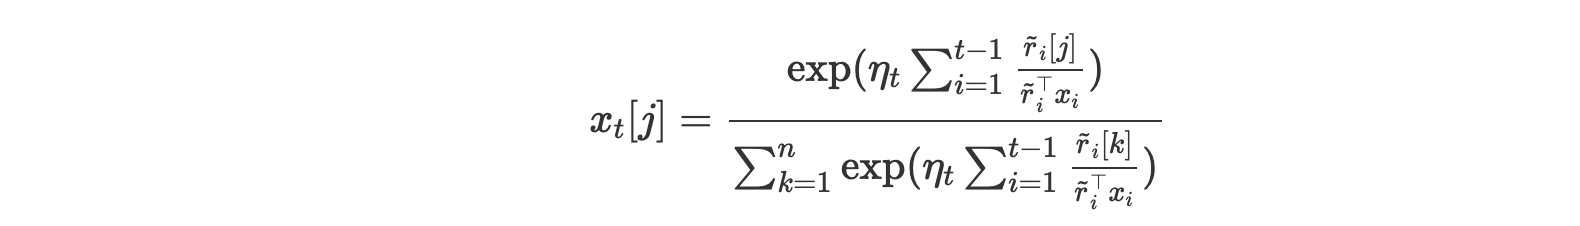



Instead of picking the portfolio $x_t$ we select the perturbed portfolio:$$\tilde{x}_t[j] = (1-\alpha_t)x_t[j] + \frac{\alpha_t}{n}$$

With the choice $\eta_t = \frac{\alpha_t}{n}\sqrt{\frac{log(n)}{t}}$, $\alpha_t = n^{1/2}(log(n))^{1/4} t^{-1/4}$

$R_{T}(\tilde{EG}(\eta_t, \alpha_t), r_1^T, x) \leq O(n^{1/2} (log n)^{1/4} T^{3/4})$

In [ ]:
def Best_Constantly_Rebalanced_Portfolio(r):
    T = r.shape[0]
    n = r.shape[1]
    if T == 0:
        return np.ones(n) / n

    x = cp.Variable(n)

    obj = cp.sum(cp.log(r @ x))
    prob = cp.Problem(cp.Maximize(obj), [cp.sum(x) == 1, x >= 0])
    prob.solve()
    return x.value


def Follow_The_Linearized_Leader(r):
    T = len(r)
    n = len(r[0])
    x = np.zeros((T, n))
    theta = 0

    for t in range(T):
        x[t][np.argmax(theta)] = 1.0
        gradient = -r[t] / np.dot(r[t], x[t])
        theta = theta - gradient
    return x


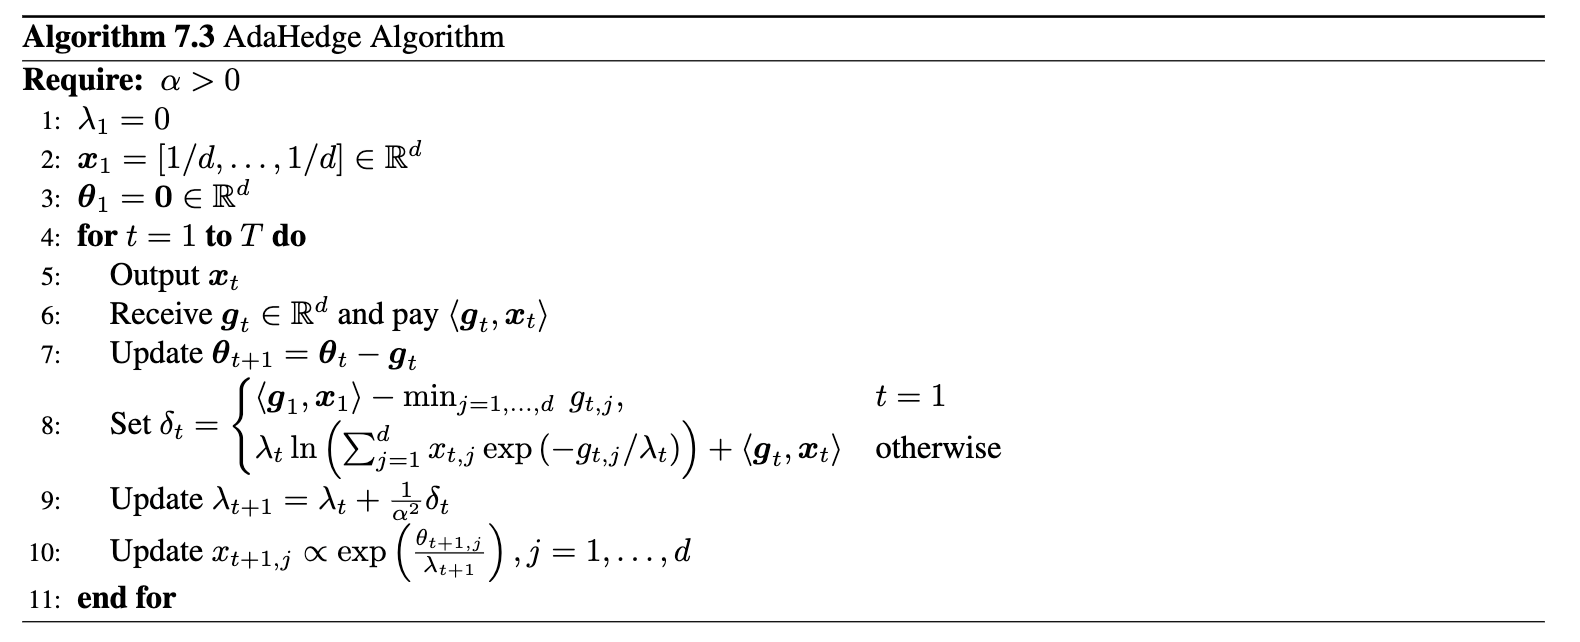

In [26]:
from scipy.special import logsumexp


def exp_normalize(x):
    b = x.max()
    y = np.exp(x - b)
    return y / y.sum()


def AdaHedge(r):
    T = r.shape[0]
    n = r.shape[1]
    if T == 0:
        return np.ones(n) / n

    alpha_squared = np.log(n)
    lamda = 0
    theta = 0

    x = np.zeros((T, n))
    x_t_plus_1 = np.ones(n) / n
    for t in range(T):
        x[t] = x_t_plus_1

        gradient = -r[t] / np.dot(r[t], x[t])
        theta = theta - gradient
        if t == 0:
            delta = np.dot(gradient, x[t]) - np.min(gradient)
        else:
            delta = np.dot(gradient, x[t]) + lamda * logsumexp(
                a=-gradient / lamda, b=x[t]
            )

        lamda = lamda + delta / alpha_squared

        x_t_plus_1 = exp_normalize(theta / lamda)

    return x


# Exponentiated Gradient

**А МОЖНО КАК-ТО ИЗБАВИТЬСЯ ОТ $r$ В РЕГРЕТЕ?**

$$\tilde{r}_t ← (1-\frac{\alpha_t}{n})r_t + \frac{\alpha_t}{n} 1$$

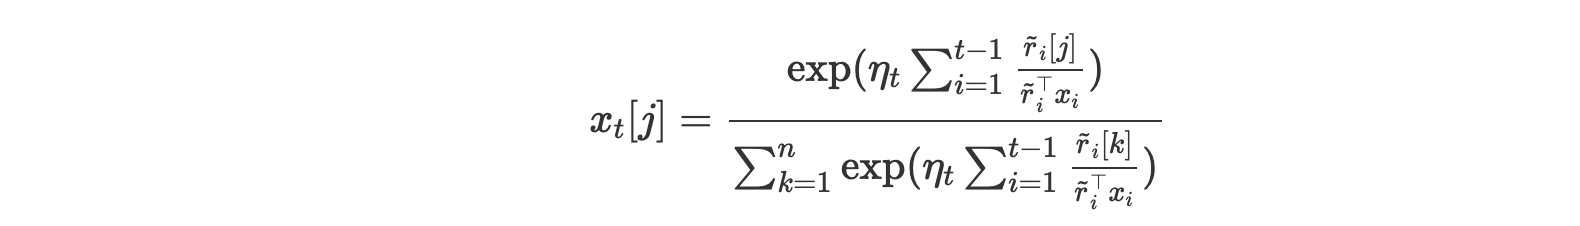



Instead of picking the portfolio $x_t$ we select the perturbed portfolio:$$\tilde{x}_t[j] = (1-\alpha_t)x_t[j] + \frac{\alpha_t}{n}$$

With the choice $\eta_t = \frac{\alpha_t}{n}\sqrt{\frac{log(n)}{t}}$, $\alpha_t = n^{1/2}(log(n))^{1/4} t^{-1/4}$

$R_{T}(\tilde{EG}(\eta_t, \alpha_t), r_1^T, x) \leq O(n^{1/2} (log n)^{1/4} T^{3/4})$

вот [здесь](https://onlinelibrary.wiley.com/doi/epdf/10.1111/1467-9965.00058) можно посмотреть

In [ ]:
def EG_tilde(r):
    T = r.shape[0]
    n = r.shape[1]
    if T == 0:
        return np.ones(n) / n

    x = np.zeros((T, n))
    tilde_x_t_plus_1 = np.ones(n) / n
    x_t_plus_1 = np.ones(n) / n
    theta = 0
    for t in range(T):
        x[t] = tilde_x_t_plus_1

        alpha_t = (n * n * np.log(n) / (t + 1)) ** 0.25

        eta_t = alpha_t / n * np.sqrt(np.log(n) / (t + 1))

        tilde_r = (1 - alpha_t / n) * r[t] + alpha_t / n

        gradient = -tilde_r / np.dot(tilde_r, x_t_plus_1)

        theta = theta - gradient

        x_t_plus_1 = exp_normalize(eta_t * theta)
        tilde_x_t_plus_1 = (1 - alpha_t) * x_t_plus_1 + alpha_t / n

    return x

# Simulation Experiment

In [ ]:
# Number of stocks
n = 5
# Create dummy stock labels
dummy_stocks = ["".join(random.choices(string.ascii_uppercase, k=5)) for i in range(n)]
# Number of trading days
T = 700

# Log-normal returns
r = np.exp(np.random.normal([0.01, 0, 0.02, -0.01, -0.02], 0.2, size=(T, n)))
df = pd.DataFrame(data=r.cumprod(axis=0), columns=dummy_stocks)

<Axes: >

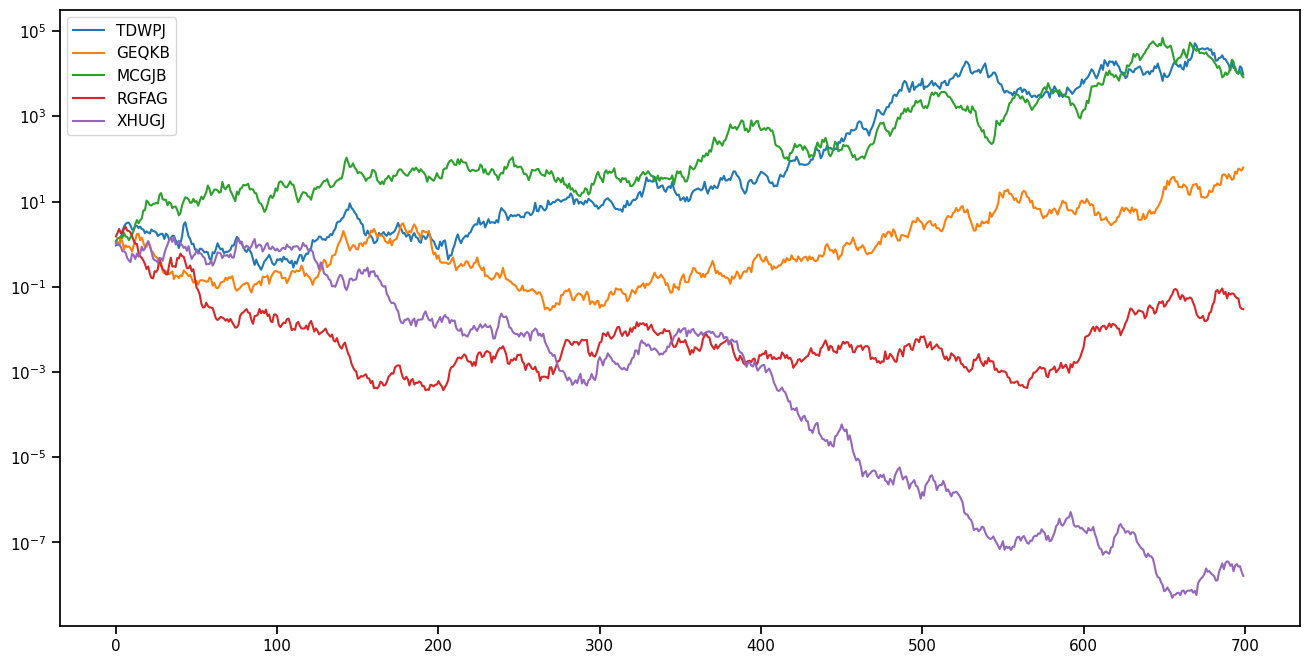

In [21]:
df.plot(logy=True)

In [ ]:
adahedge = AdaHedge(r)
df["ADAHEDGE"] = np.cumprod(np.sum(r * adahedge, axis=1))

eg = EG_tilde(r)
df["EG"] = np.cumprod(np.sum(r * eg, axis=1))

ftll = Follow_The_Linearized_Leader(r)
df["FTLL"] = np.cumprod(np.sum(r * ftll, axis=1))

In [ ]:
bcrp = Best_Constantly_Rebalanced_Portfolio(r)
df["BCRP"] = np.cumprod(r @ bcrp)
df["UCRP"] = np.cumprod(np.sum(r * (np.ones(n) / n), axis=1))

<Axes: >

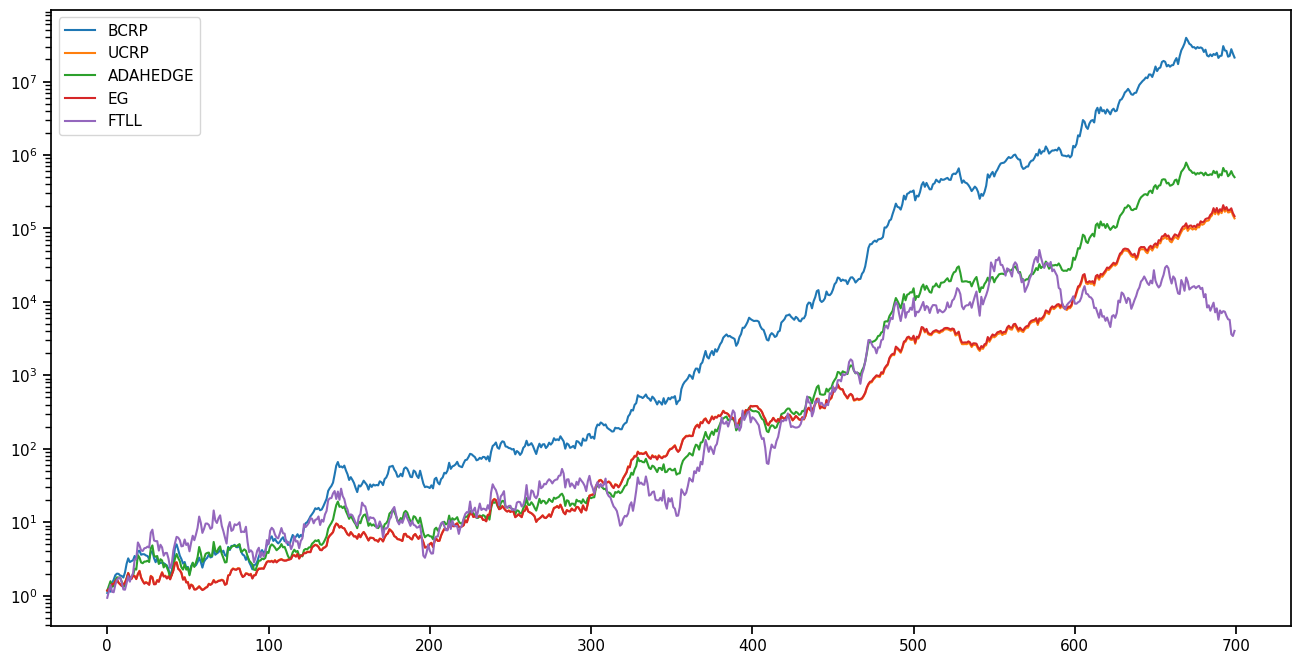

In [ ]:
df[["BCRP", "UCRP", "ADAHEDGE", "EG", "FTLL"]].plot(logy=True)

# MARKET DATA

In [ ]:
# Date range
start = "2023-03-25"
end = "2025-03-25"

# Tickers of assets
assets = ["JPM", "NFLX", "XOM", "VZ", "META"]
assets.sort()
n = len(assets)
# Downloading data
data = yf.download(assets, start=start, end=end)
data = data.loc[:, ("Close", slice(None))]
data.columns = assets

# Calculating returns

df = 1 + data[assets].pct_change().dropna() / 100
r = df.to_numpy()
df = df.cumprod(axis=0)

[*********************100%***********************]  5 of 5 completed


<Axes: xlabel='Date'>

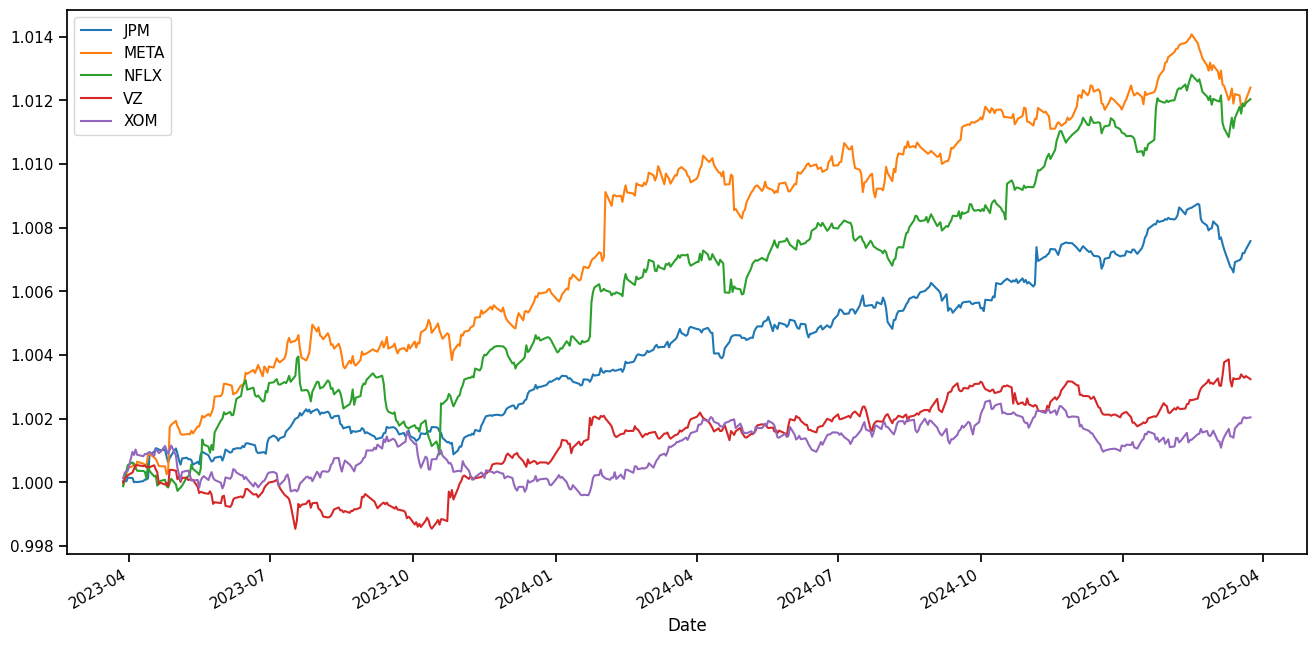

In [26]:
df.plot()

In [ ]:
adahedge = AdaHedge(r)
df["ADAHEDGE"] = np.cumprod(np.sum(r * adahedge, axis=1))

eg = EG_tilde(r)
df["EG"] = np.cumprod(np.sum(r * eg, axis=1))

ftll = Follow_The_Linearized_Leader(r)
df["FTLL"] = np.cumprod(np.sum(r * ftll, axis=1))

In [ ]:
bcrp = Best_Constantly_Rebalanced_Portfolio(r)
df["BCRP"] = np.cumprod(r @ bcrp)
df["UCRP"] = np.cumprod(np.sum(r * (np.ones(n) / n), axis=1))

<Axes: xlabel='Date'>

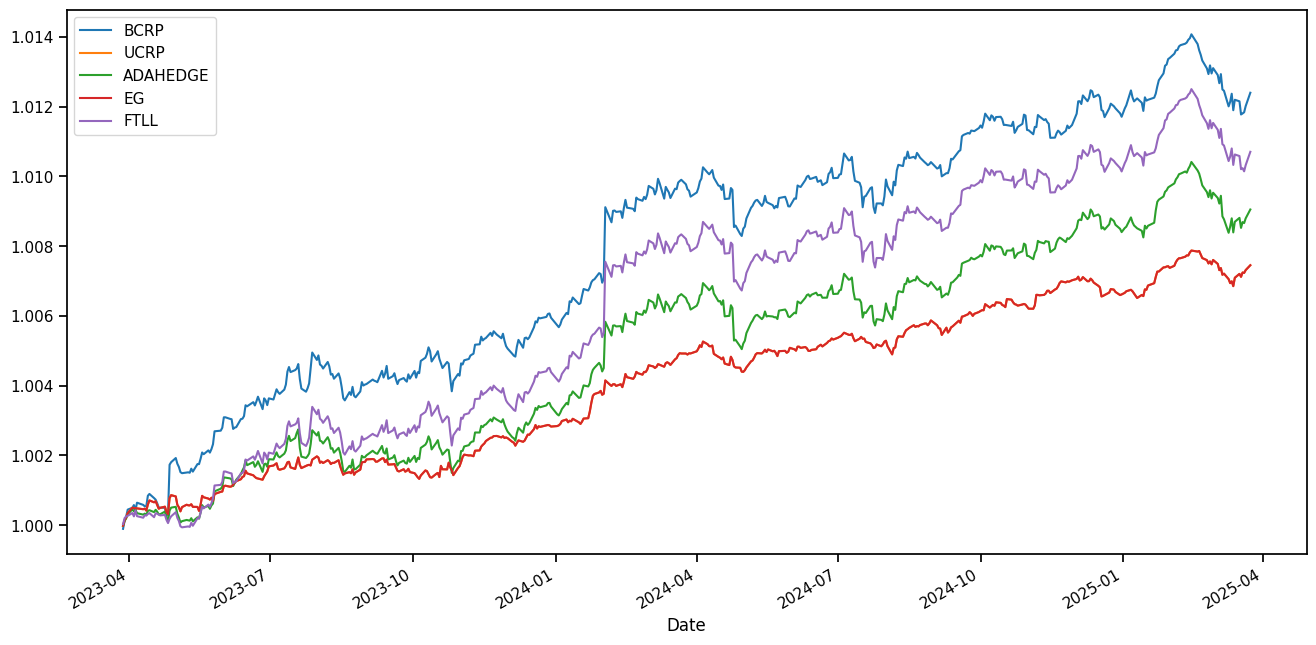

In [ ]:
df[["BCRP", "UCRP", "ADAHEDGE", "EG", "FTLL"]].plot()